# Data Visualization
Data visualization is one of the most important ways to understand and communicate data.\
There are several reasons why data visualization is important which are:
- It allows you to identify patterns in the data that might be difficult to detect just by looking \
at data numbers or labels.
- Data visualizations can reveal outliers, mistakes or other issues that can negatively impact analysis.
- Showing data in graphs and charts can help non-expert understand the important findings from the analysis.


# How to visualize data
Not all datasets can be visualized in the same way, appropriate data visualizations depends on\
the data type and how you want tje data to be communicated and interpreted

## Bar plots
Bar plot is a data visualization tool that represents categorical data using rectangular bars with heights\
proportional to the values they represent. They are used to compare magnitudes across discrete categories.

### Key Features
- Axes: Bar charts have two axes, one for the categories being compared and one for the numerical value (frequency or measurement).
- Bars: Equal width bars are used for consistent visual comparison, with gaps between them.
- Orientation: Vertical bar charts are often called column charts, while horizontal bars are useful for longer category labels.
- Scale: The numeric axis should typically start at zero to avoid distorting data comparisons.

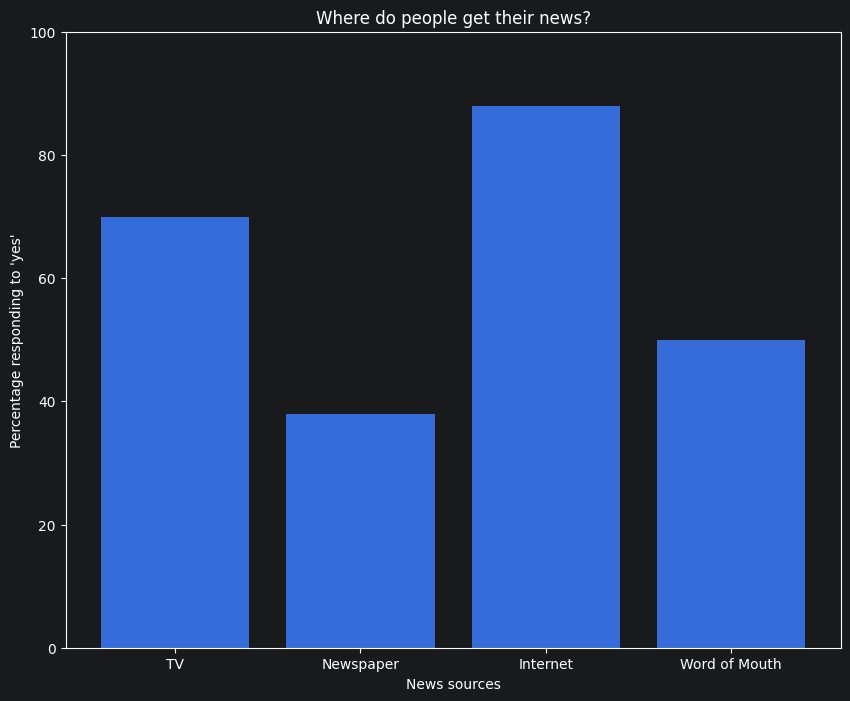

In [68]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(seed=42)

news_sources = [70, 38, 88, 50]
source_labels = ["TV", "Newspaper", "Internet", "Word of Mouth"]

plt.figure(figsize=(10, 8))
plt.bar(source_labels, news_sources)

plt.title("Where do people get their news?", loc="center")
plt.ylabel("Percentage responding to 'yes'")
plt.ylim([0, 100])
plt.xlabel("News sources")
plt.show()

## Pie Charts
Pie chart is a circular statistical graphic divided into slices to illustrate numerical proportion,\
where each slice represents a category's percentage of the total 100%. Used for comparing parts of a\
whole at a set point in time, they are best with few categories. The arc length of each slice is proportional to the quantity it represents.

### Key Features
- Purpose: Ideal for showing proportional relationships, such as market share or survey results.
- Limitations: Not effective for changes over time or when there are too many categories, which makes them difficult to read.
- Design: For better readability, sort slices in descending order starting from the top and use direct labels instead of a legend.

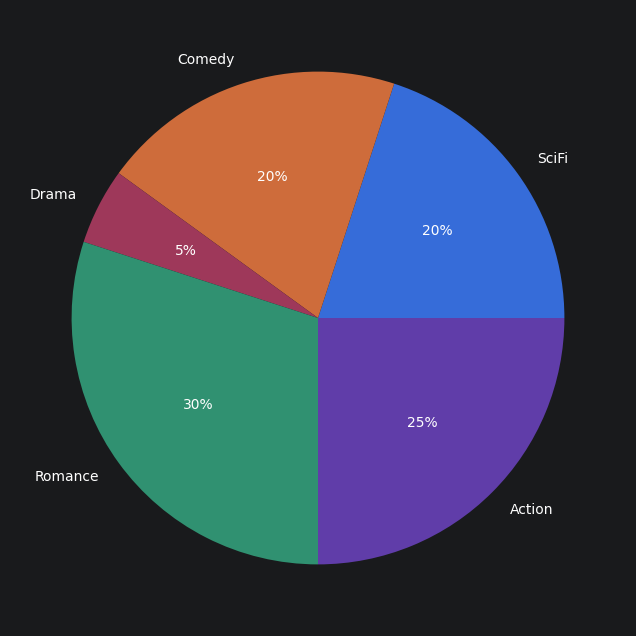

In [69]:
favourite_movie_genres = [20, 20, 5, 30, 25]
movie_genres = ["SciFi", "Comedy", "Drama", "Romance", "Action"]

plt.figure(figsize=(10, 8))
plt.pie(favourite_movie_genres, labels=movie_genres, autopct="%.0f%%")
plt.show()

## Box Plots
Boxplot is a standardized graphical method for displaying the distribution of numerical data based on a\
five-number summary: minimum, first quartile Q1, median Q2, third quartile Q3, and maximum.\
It highlights data skewness, dispersion, and outliers. The central box represents the\
interquartile range (IQR), spanning the middle 50% of the data

### Key Features
- Median (Line inside the box): The middle value of the dataset.
- Box (Q1 to Q3): Represents the interquartile range (IQR), containing the middle 50% of the data.
- Whiskers: Lines extending from the box to the minimum and maximum values (excluding outliers).
- Outliers: Individual points plotted beyond the whiskers, representing anomalies or extreme values.

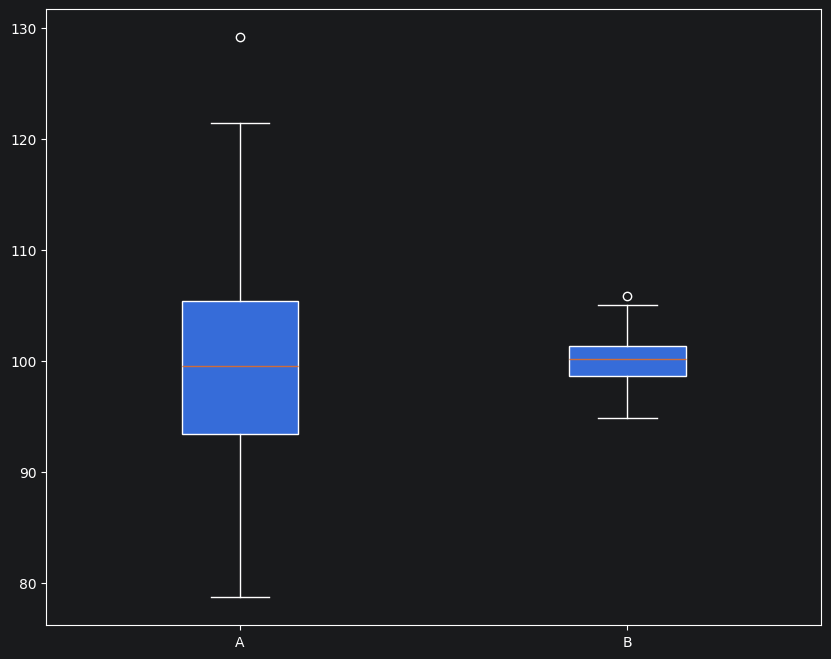

In [70]:
data = np.hstack(
    (rng.normal(loc=100, scale=10, size=(200, 1)),
     (rng.normal(loc=100, scale=2, size=(200, 1))))
)

plt.figure(figsize=(10, 8))
plt.boxplot(data, patch_artist=True, widths=0.3)
plt.xticks(range(1, 3), ["A", "B"])
plt.show()

## Histograms
Histogram is a data visualization chart that represents the distribution of numerical data by grouping\
continuous data into equal-sized intervals or "bins". It displays frequency (count of data points)\
on the Y-axis and ranges (bins) on the X-axis, showing the center, shape, and spread of data.

### Key Features
- Purpose: Used to understand the distribution of continuous variables.
- Bins/Intervals: Data is grouped into intervals (e.g., 0-10, 10-20), with vertical bars representing the number of data points within each bin.
- Histogram vs. Bar Chart: Unlike bar charts (which compare discrete categories), histogram bars represent frequency density and are usually adjacent.

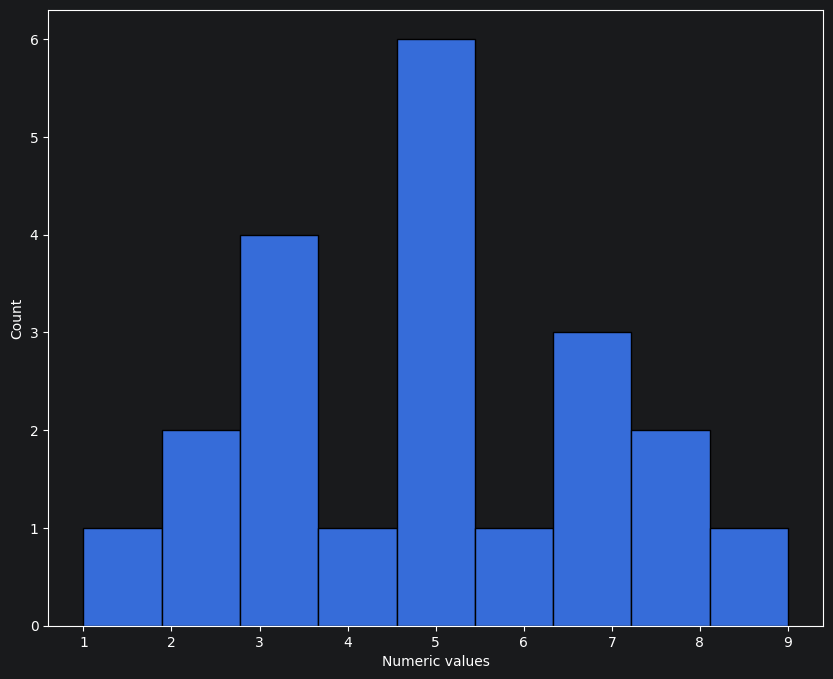

In [71]:
X = [1, 2, 2, 3, 3, 4, 5, 5, 5, 5, 6, 7, 7, 7, 8, 8, 9, 3, 3, 5, 5]

plt.figure(figsize=(10, 8))
plt.hist(X, bins=len(set(X)), edgecolor="black")
plt.xlabel("Numeric values")
plt.ylabel("Count")
plt.show()

# Coding Exercises

## Exercise 1
Create a bar plot. Start by generating a 4×3 matrix of numbers in a dataframe (use pandas if you’re working in Python).\
You can write out the matrix manually, or reshape a vector of the numbers 0 through 11.\
Show two bar plots with the data grouped by row or by column

In [72]:
import pandas as pd

data = rng.integers(low=0, high=12, size=(4, 3))
df = pd.DataFrame(data, columns=["A", "B", "C"])
df

,A,B,C
0,5,1,10
1,9,9,2
2,0,10,3
3,7,10,0


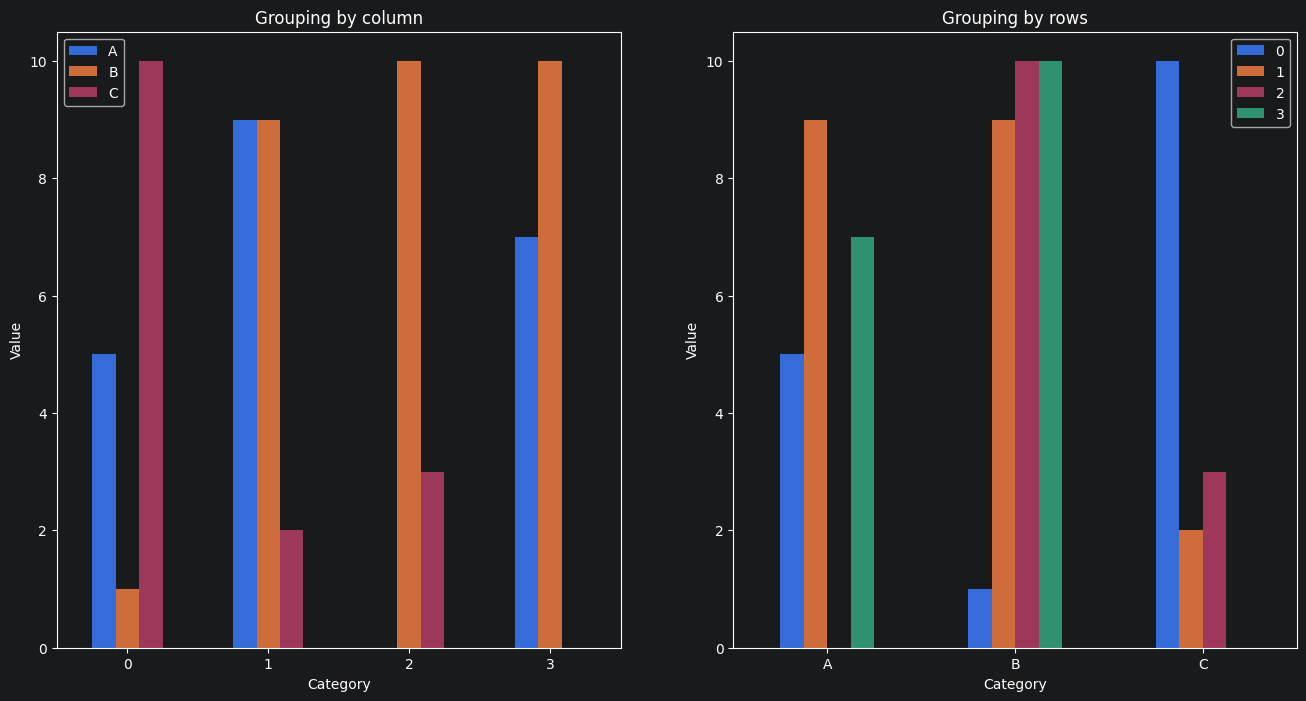

In [73]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

df.plot(kind="bar", ax=ax[0], title="Grouping by column", xlabel="Category", rot=0, ylabel="Value")
df.T.plot(kind="bar", ax=ax[1], title="Grouping by rows", xlabel="Category", rot=0, ylabel="Value")
plt.show()

## Exercise 2
Create a data matrix containing 30 observations and six features (thus, a 30 × 6 matrix).\
The data matrix is called Y, and the data in the i<sup>th</sup> column are generated using the following formula:\
Y<sub>i</sub> ∼ N(µ<sub>i</sub>, σ<sub>i</sub><sup>2</sup>)\
µ<sub>i</sub> = (i + 1)<sup>2</sup>\
σ = 30 (2i / 5 - 1)<sup>2</sup>

In [74]:
num_rows = 30
num_cols = 6

Y = np.empty((num_rows, num_cols))
for i in range(num_cols):
    mu = (i + 1) ** 2
    sigma = 30 * (( 2 * i / (5 - 1)) ** 2)
    Y[:, i] = rng.normal(loc=mu, scale=sigma**2, size=num_rows)

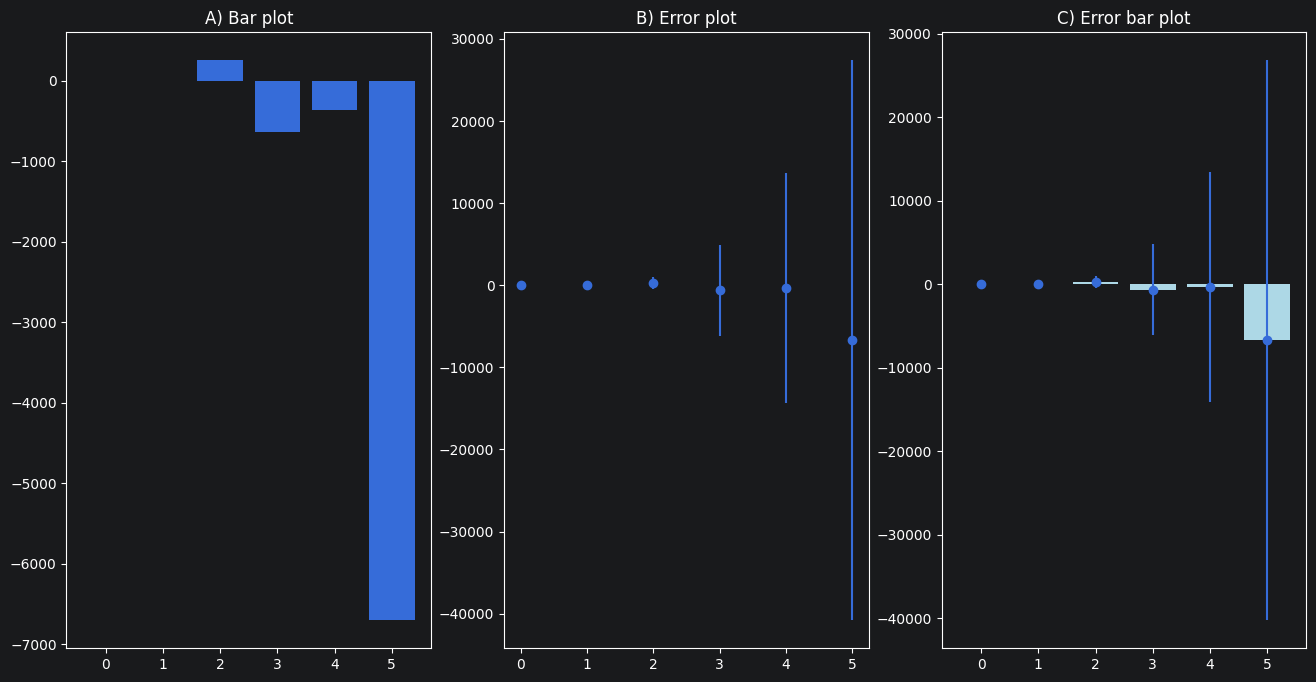

In [75]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

ax[0].bar(range(num_cols), np.mean(Y, axis=0))
ax[0].set_title("A) Bar plot")

ax[1].errorbar(range(num_cols), np.mean(Y, axis=0), yerr=np.std(Y, axis=0, ddof=1), fmt="o")
ax[1].set_title("B) Error plot")

ax[2].bar(range(num_cols), np.mean(Y, axis=0), color="lightblue")
ax[2].errorbar(range(num_cols), np.mean(Y, axis=0), yerr=np.std(Y, axis=0), fmt="o")
ax[2].set_title("C) Error bar plot")

plt.show()

## Exercise 3
Given the table below which contains a dataset of 63 people who were asked to state\
their favorite ice cream flavor
| Flavor | Number of People |
| :----: | :--------------: |
| Chocolate | 24 |
| Vanilla | 16 |
| Strawberry | 7 |
| Pistachio | 16 |

Are these data appropriate for a pie chart? Showthese data in a pie chart

In [76]:
data = {
    "Chocolate": 24,
    "Vanilla": 16,
    "Strawberry": 7,
    "Pistachio": 16
}

if sum(data.values()) == 63:
    print("The data is appropriate for a pie chart")
else:
    print("The data is not appropriate for a pie chart")

The data is appropriate for a pie chart


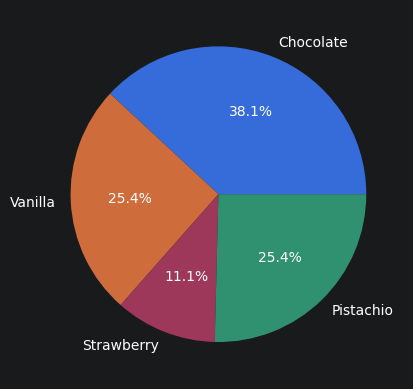

In [77]:
plt.pie(data.values(), labels=data.keys(), autopct="%.1f%%")
plt.show()

## Exercise 4
Write a code to display the line plot given the data which contains 500 numbers randomly drawn\
from a gamma distribution using the parameters shape=scale=1 (use the numpy function random.gamma).\
Use numpy’s histogram function to extract the x and y axis values, which correspond to the bin boundaries and counts\
of data values in each bin. Then draw a line plot for the histogram values. (Note that numpy’s histogram function returns\
bin boundaries; you will need to compute the center points of each bin).

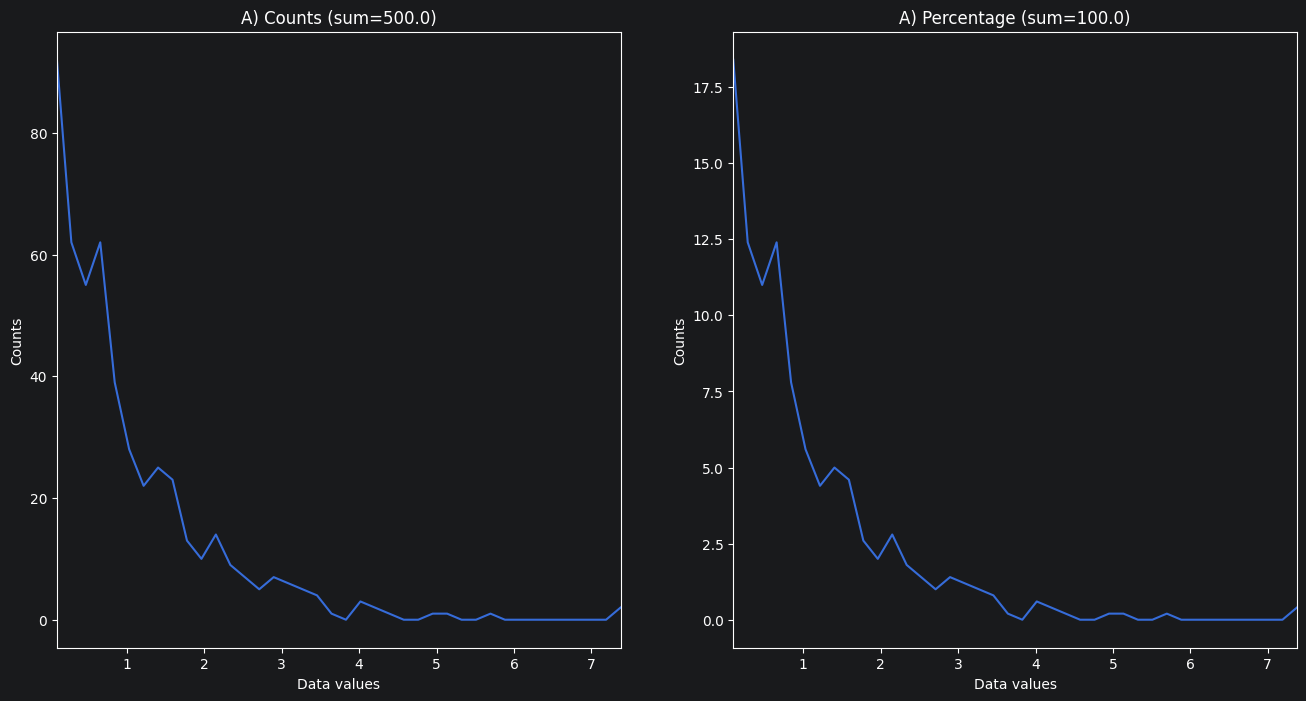

In [78]:
data = rng.gamma(shape=1, scale=1, size=500)
counts, boundaries = np.histogram(data, bins=40)

# Compute center points
boundaries = (boundaries[:-1] + boundaries[1:]) / 2

# Normalize counts to percentage
counts_percentage = (100 * counts) / np.sum(counts)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].plot(boundaries, counts)
ax[0].set_xlim(boundaries[[0, -1]])
ax[0].set_title(f"A) Counts (sum={np.sum(counts):.1f})")
ax[0].set_xlabel("Data values")
ax[0].set_ylabel("Counts")

ax[1].plot(boundaries, counts_percentage)
ax[1].set_xlim(boundaries[[0, -1]])
ax[1].set_title(f"A) Percentage (sum={np.sum(counts_percentage):.1f})")
ax[1].set_xlabel("Data values")
ax[1].set_ylabel("Counts")
plt.show()

## Exercise 5
This exercise will help you decide whether to use bars or lines in histograms.\
First, generate two datasets, each of size N = 200, as random numbers that are\
drawn from a normal or exponential distribution, according to the following equations:\
G ~ N(2, 1) \
E ~ exp(N(0, 1)) \
Create two histogram plots, one created by entering the data directly into plt.hist(), \
and one created by extracting histogram information using np.histogram() and plotting the\
histograms as lines. Produce a graph using the same bins for both datasets (that is, the same\
boundaries for data G and E) and 30 bins. Note that these two graphs show distributions of exactly\
the same data but plotted using either bars (with some transparency) or lines.

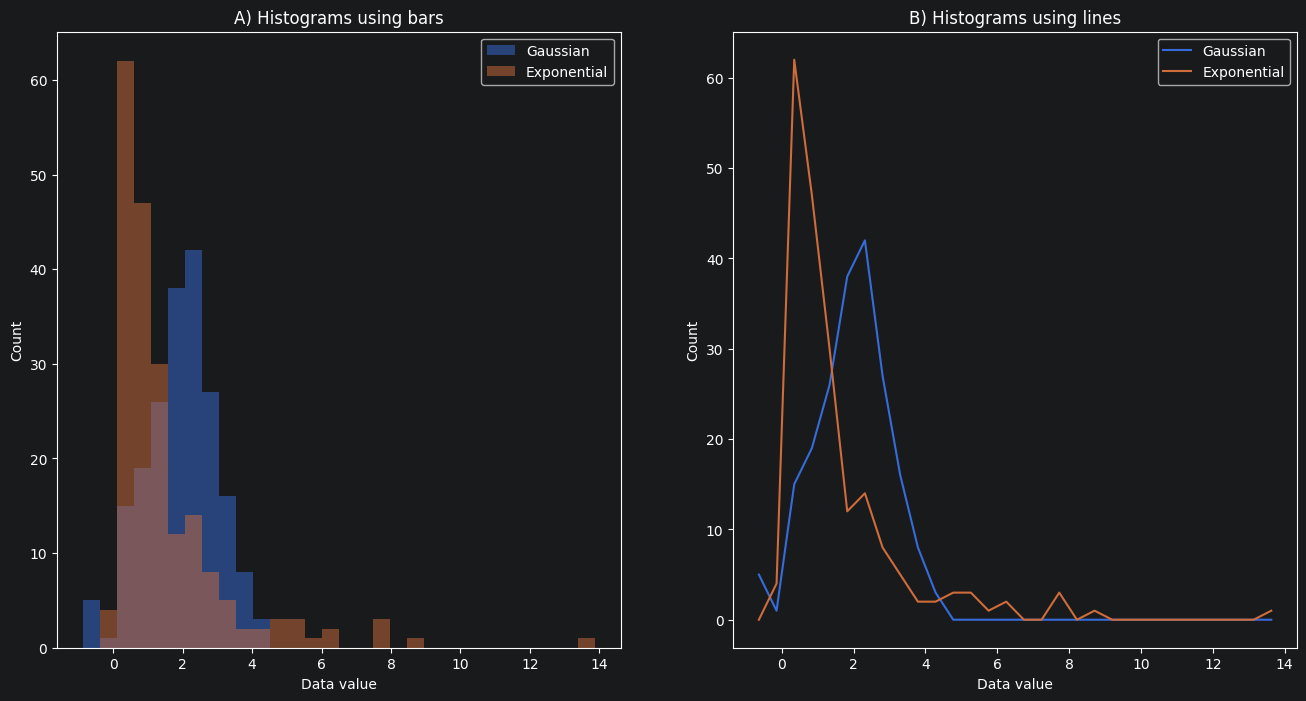

In [102]:
N = 200
G = rng.normal(loc=2, scale=1, size=N)
E = np.exp(rng.normal(loc=0, scale=1, size=N))
num_bins = 30

data = np.hstack((G, E))
bins = np.linspace(data.min(), data.max(), num_bins + 1)

counts_G, boundaries_G = np.histogram(G, bins=bins)
counts_E, boundaries_E = np.histogram(E, bins=bins)

boundaries_G = (boundaries_G[:-1] + boundaries_G[1:]) / 2
boundaries_E = (boundaries_E[:-1] + boundaries_E[1:]) / 2

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].hist(G, bins=bins, label="Gaussian", alpha=0.5)
ax[0].hist(E, bins=bins, label="Exponential", alpha=0.5)
ax[0].legend()
ax[0].set_title("A) Histograms using bars")
ax[0].set_xlabel("Data value")
ax[0].set_ylabel("Count")


ax[1].plot(boundaries_G, counts_G, label="Gaussian")
ax[1].plot(boundaries_E, counts_E, label="Exponential")
ax[1].legend()
ax[1].set_title("B) Histograms using lines")
ax[1].set_xlabel("Data value")
ax[1].set_ylabel("Count")

plt.show()